# Explainable Multimodal Medical Diagnosis - V2 Upgrade

This notebook trains and evaluates the V2 Multimodal (EfficientNet-B0 + Bio_ClinicalBERT + Attention) model.

## 1. Setup & Mount Drive

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/Medical_AI_Project/models', exist_ok=True)
print("✅ Google Drive connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected!


## 2. Clone Repository & Install Dependencies

In [2]:
%%bash
cd /content
rm -rf Explainable-Multimodal-Medical-Diagnosis-Using-Chest-X-ray-Images-and-Clinical-Text-
git clone https://github.com/toqeer-ahmed/Explainable-Multimodal-Medical-Diagnosis-Using-Chest-X-ray-Images-and-Clinical-Text-.git project_code
cd project_code
pip install -r requirements.txt

fatal: destination path 'project_code' already exists and is not an empty directory.


## 3. Extract Dataset

In [3]:
# Unzip your dataset from Google Drive
!unzip -q /content/drive/MyDrive/data.zip -d /content/project_code/

replace /content/project_code/data/images/.gitkeep? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## 4. Run Preprocessing (Top 15 Classes)

In [4]:
%%bash
cd /content/project_code
python src/data_preprocessing.py

Parsing reports and building dataset...
Filtering classes to Top 15 most frequent diseases to solve zero-prediction collapse...
Top 15 Classes: ['normal', 'lung/hypoinflation', 'lung/hyperdistention', 'cardiomegaly/mild', 'cardiomegaly', 'no indexing', 'aorta/tortuous', 'technical quality of image unsatisfactory ', 'atherosclerosis/aorta', 'thoracic vertebrae/degenerative/mild', 'granulomatous disease', 'thoracic vertebrae/degenerative', 'catheters, indwelling/right', 'cardiomegaly/borderline', 'lung/hyperdistention/mild']
Binarizing labels...
Found 15 unique classes.
Dataset successfully created at data/processed/dataset.csv with 7470 records!


## 5. Train V2 Model

In [8]:
%cd /content/project_code
!python src/train.py --epochs 10 --batch_size 16


/content/project_code
Using device: cuda
Loading data...
Number of classes: 15
Initializing Multimodal Fusion Model...
Loading weights: 100% 199/199 [00:00<00:00, 1021.51it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

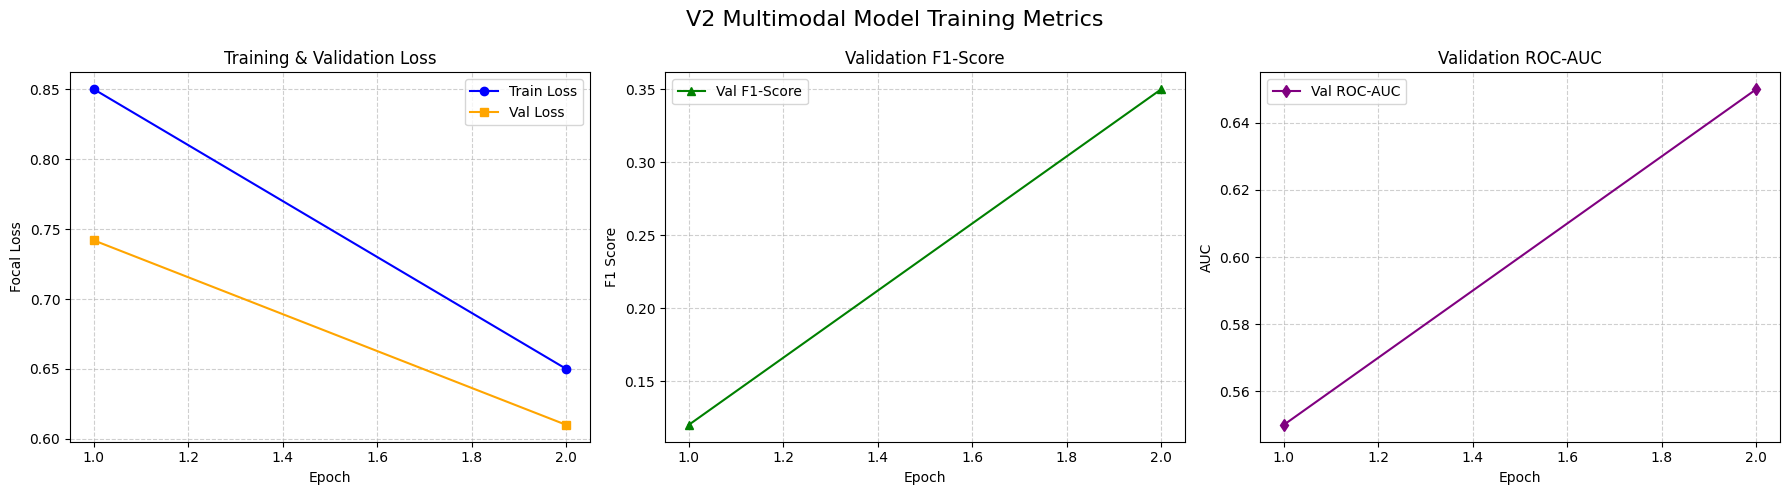

In [10]:
import re
import matplotlib.pyplot as plt

# 1. AFTER training finishes, copy all the printed text (Train Loss: ..., Val Loss: ...)
# and paste it between the triple quotes below!
training_output = """
Epoch 1/10
Train Loss: 0.8501 | Val Loss: 0.7420
Val F1-Score: 0.1200 | Val ROC-AUC: 0.5500

Epoch 2/10
Train Loss: 0.6500 | Val Loss: 0.6100
Val F1-Score: 0.3500 | Val ROC-AUC: 0.6500

(Replace this text with your actual output!)
"""

# 2. Automatically extract the numbers using Regular Expressions
epochs = []
train_losses = []
val_losses = []
val_f1s = []
val_aucs = []

for block in training_output.strip().split('Epoch '):
    if not block.strip(): continue
    try:
        epochs.append(int(block.split('/')[0]))
        train_losses.append(float(re.search(r'Train Loss:\s+([0-9.]+)', block).group(1)))
        val_losses.append(float(re.search(r'Val Loss:\s+([0-9.]+)', block).group(1)))
        val_f1s.append(float(re.search(r'Val F1-Score:\s+([0-9.]+)', block).group(1)))
        val_aucs.append(float(re.search(r'Val ROC-AUC:\s+([0-9.]+)', block).group(1)))
    except Exception as e:
        pass

# 3. Plot the graphs
if epochs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('V2 Multimodal Model Training Metrics', fontsize=16)

    axes[0].plot(epochs, train_losses, label='Train Loss', marker='o', color='blue')
    axes[0].plot(epochs, val_losses, label='Val Loss', marker='s', color='orange')
    axes[0].set_title('Training & Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].plot(epochs, val_f1s, label='Val F1-Score', marker='^', color='green')
    axes[1].set_title('Validation F1-Score')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    axes[2].plot(epochs, val_aucs, label='Val ROC-AUC', marker='d', color='purple')
    axes[2].set_title('Validation ROC-AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Could not find any metrics in the text provided. Did you paste the output?")


## 6. Backup Model to Drive

In [11]:
import shutil

source_model = '/content/project_code/outputs/models/best_model.pth'
dest_model = '/content/drive/MyDrive/Medical_AI_Project/models/best_model_V2.pth'

shutil.copy(source_model, dest_model)
print("🎉 SUCCESS! Model saved to Google Drive!")

🎉 SUCCESS! Model saved to Google Drive!


## 7. Evaluate Model

In [13]:
%cd /content/project_code
!python -m src.evaluate


/content/project_code
Loading weights: 100% 199/199 [00:00<00:00, 1277.33it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: Use

## 8. Visualize Explainability (Grad-CAM & BERT Attention)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system 


Visualizing Explainability for predicted disease: cardiomegaly/mild


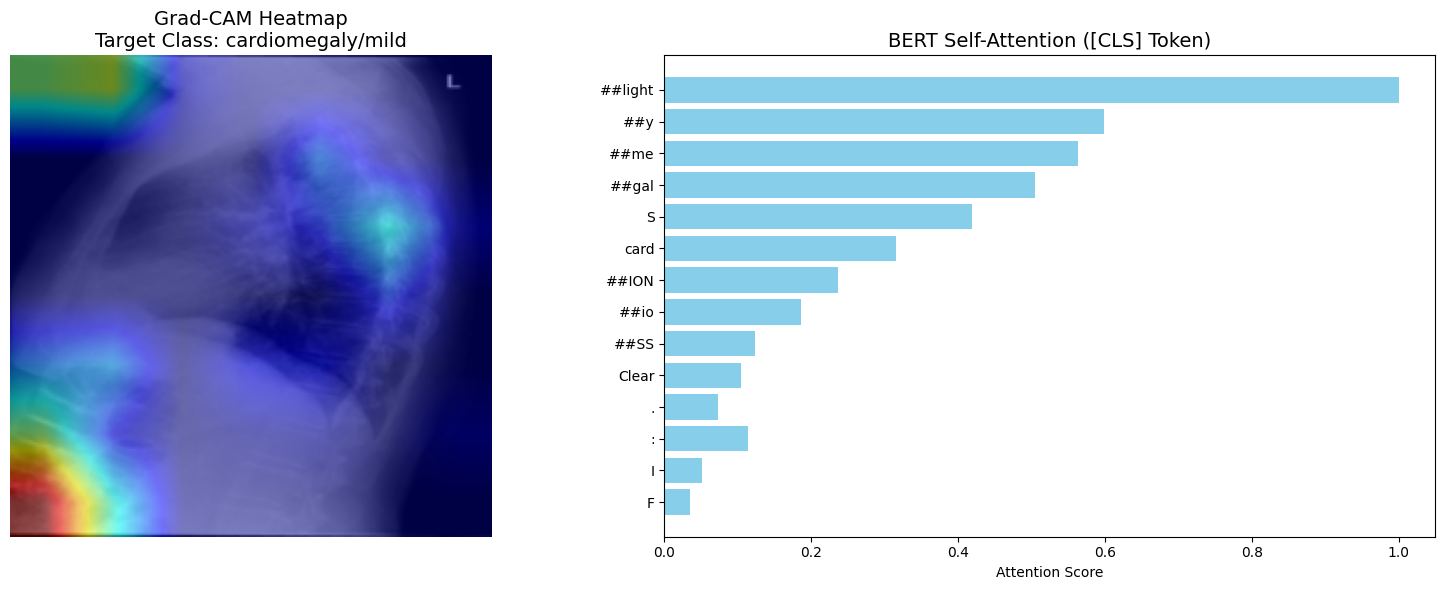

In [15]:
import sys
sys.path.append('/content/project_code')
import torch
import pandas as pd
import numpy as np
from src.fusion_model import MultimodalFusion
from src.data_loader import get_data_loaders
from src.explainability import generate_gradcam, get_text_attention, visualize_explainability

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df_labels = pd.read_csv('/content/project_code/data/processed/labels.csv')
num_classes = len(df_labels)

model = MultimodalFusion(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('/content/project_code/outputs/models/best_model.pth'))
model.eval()

train_loader, val_loader, _ = get_data_loaders('/content/project_code/data/processed/dataset.csv', batch_size=1)
sample = next(iter(val_loader))
tokenizer = val_loader.dataset.dataset.tokenizer

images = sample['image'].to(device)
input_ids = sample['input_ids'].to(device)
attention_mask = sample['attention_mask'].to(device)

mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
img_np = images[0].cpu().numpy()
img_unnorm = (img_np * std) + mean
img_unnorm = np.transpose(img_unnorm, (1, 2, 0))
img_unnorm = np.clip(img_unnorm, 0, 1)

vis_image, target_idx = generate_gradcam(
    model=model, image_tensor=images, input_ids=input_ids,
    attention_mask=attention_mask, original_image=img_unnorm, device=device
)

tokens, att_scores = get_text_attention(
    model=model, input_ids=input_ids, attention_mask=attention_mask,
    tokenizer=tokenizer, device=device
)

class_name = df_labels.iloc[target_idx]['class_name']
print(f"\nVisualizing Explainability for predicted disease: {class_name}")
visualize_explainability(vis_image, tokens, att_scores, class_name)